# Air compressor analysis

On Monday, the 9th of June, we saw a huge drop in air pressure inside the M1M3 (almost 0) and realized that the Air Compressor 2 was off. 

Telemetry showed that it had been off since Wednesday 4th of June. We wanted to examine the telemetry (and events) of the Air compressor 2 in this period to understand why it was off. 

We turned it back on using the run_command, and there was a power glitch reported on Thursday, 5th of June, when Bruno remembered he turned it back on (not shown in the telemetry). 

In [24]:
from astropy.time import Time
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from lsst.summit.utils.efdUtils import getEfdData, makeEfdClient
from lsst.summit.utils.tmaUtils import TMAEventMaker

import matplotlib.dates as mdates


We select the data of telemetry and events between 4th and 10 of June

In [2]:
# Create an EFD client instance
client = makeEfdClient()

In [3]:
start = Time("2025-06-04T00:00:00Z", scale="utc")
end = Time("2025-06-10T00:00:00Z", scale="utc")

telemetry = await client.select_time_series(
    'lsst.sal.MTAirCompressor.analogData',
    ['*'], 
    start, 
    end
)

events = await client.select_time_series(
    'lsst.sal.MTAirCompressor.logevent_status',
    ['*'], 
    start, 
    end
)


events_error   = await client.select_time_series(
    'lsst.sal.MTAirCompressor.logevent_errors',
    ['*'], 
    start, 
    end
)

## Event

We analyze whether any faults have been recorded in the events

In [4]:
# Separate en Air Compressor 1 and 2
salIndex1 = events[events['private_identity']=="MTAirCompressor:1"]
salIndex2 = events[events['private_identity']=="MTAirCompressor:2"]

In [5]:
# Number of fails from 2025-06-04 to  2025-06-10
fault_count_1 = np.sum(salIndex1['fault'])
fault_count_2 = np.sum(salIndex2['fault'])

print(f'Number of faults of AirCompressor 1: {fault_count_1}')
print(f'Number of faults of AirCompressor 2: {fault_count_2}')

Number of faults of AirCompressor 1: 0
Number of faults of AirCompressor 2: 2


The faults recorded in logevent_status are 0 for compressor 1 and 2 for compressor 2.


Let's visualize the errors found for compressor 2

In case you want to examine compressor 1 (this time we will not do it because no errors are shown) you should take the data from `AirCompressor1_time` using `salIndex1`.

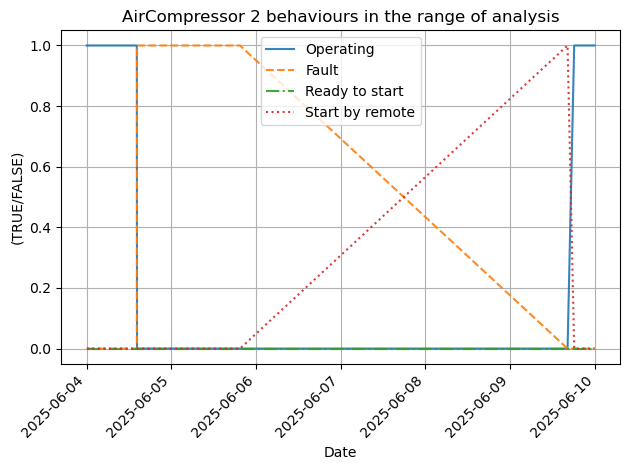

In [8]:
AirCompressor2_time = Time(salIndex2['private_efdStamp'], format='unix').datetime


# Plot de flags
fig, ax = plt.subplots()

ax.plot(AirCompressor2_time, salIndex2['operating'].astype(int),
        label='Operating', linestyle='-', linewidth=1.5, alpha=0.9)

ax.plot(AirCompressor2_time, salIndex2['fault'].astype(int),
        label='Fault', linestyle='--', linewidth=1.5, alpha=0.9)

ax.plot(AirCompressor2_time, salIndex2['readyToStart'].astype(int),
        label='Ready to start', linestyle='-.', linewidth=1.5, alpha=0.9)

ax.plot(AirCompressor2_time, salIndex2['startByRemote'].astype(int),
        label='Start by remote', linestyle=':', linewidth=1.5, alpha=0.9)


ax.legend()

ax.xaxis.set_major_locator(mdates.DayLocator()) # one tick each day"
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.grid(True)
ax.set_xlabel("Date")
ax.set_ylabel("(TRUE/FALSE)", rotation=90)
ax.set_title("AirCompressor 2 behaviours in the range of analysis")

for label in ax.get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.tight_layout()
plt.show()

As variables cannot take discrete values we analyse what is happening.

We print what kind of information is stored, e.g. the variable fault. We see that there are no discrete values, only FALSE or TRUE.

In [25]:
salIndex2['fault'].value_counts(dropna=False)

fault
False    490
True       2
Name: count, dtype: int64

In [28]:
# Let's see if the time variable has information stored for, for example, the 7th June where the graph shows a strange behaviour.
salIndex2.index = AirCompressor2_time

filtered = salIndex2.loc["2025-06-07"]

print(filtered)

Empty DataFrame
Columns: [fault, maxAllowedSpeedAchieved, minAllowedSpeedAchieved, motorStartPhase, offLoad, onLoad, operating, private_efdStamp, private_identity, private_kafkaStamp, private_origin, private_rcvStamp, private_revCode, private_seqNum, private_sndStamp, readyToStart, runOnTimer, salIndex, serviceRequired, softStop, startAfterDePressurise, startAfterDryerPreRun, startAfterPowerLoss, startByRemote, startInhibit, startWithPressureRequirement, startWithTimerControl, warning]
Index: []

[0 rows x 28 columns]


As we can see the system does not return any dataframe, so for a while the system did not register any information. From the end of 5 June until the end of 9 June.

In [29]:
# Faults
faults = salIndex2[salIndex2['fault'] == True]

print("Faults:")
print(faults[['fault']])

Faults:
                            fault
2025-06-04 14:17:47.781628   True
2025-06-05 19:27:14.269099   True


The two failures were recorded on July 4 at 14:17 and July 5 at 19:27

## Telemetry

In [30]:
# Separate en Air Compressor 1 and 2
salIndex1 = telemetry[telemetry['private_identity']=="MTAirCompressor:1"]
salIndex2 = telemetry[telemetry['private_identity']=="MTAirCompressor:2"]

In [31]:
# changed the format of time
times1 = Time(salIndex1['private_efdStamp'], format='unix').datetime
times2 = Time(salIndex2['private_efdStamp'], format='unix').datetime

We analyse all the variables recorded for the two compressors separately.

In particular, we will analyse the telemetry, in particular the Compressor Volume, the Compressor Water Level, the Compressor speed target, the Motor current, the heatsink Temperature, the dclink Voltage, the motor Speed, the motor Speed RPM, the Motor power input, the Stage 1 output pressure, the Line pressure and Stage 1 output temperature. We will show this for both air compressor to see the differences.

In [32]:
def plot_compressor(times1, salIndex1, times2, salIndex2, variable, ylabel, title):

    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    
    axs[0].plot(times1, salIndex1[variable]) 
    axs[0].set_title(f'{title} MTAirCompressor:1')
    axs[0].set_ylabel(ylabel)
    axs[0].xaxis.set_major_locator(mdates.DayLocator())  # one tick each day"
    axs[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    axs[0].grid(True)

    axs[1].plot(times2, salIndex2[variable]) 
    axs[1].set_title(f'{title} MTAirCompressor:2')
    axs[1].set_ylabel(ylabel)
    axs[1].xaxis.set_major_locator(mdates.DayLocator())  # one tick each day"
    axs[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    axs[1].grid(True)

    # Título general
    fig.suptitle(title, fontsize=16)

    for label in axs[0].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    for label in axs[1].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

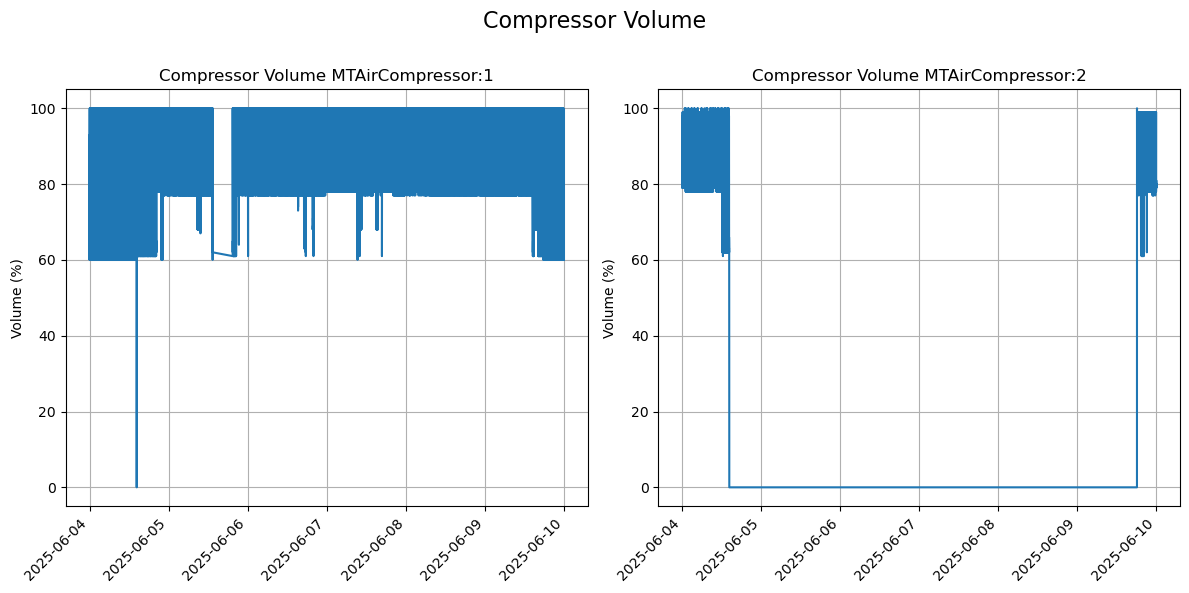

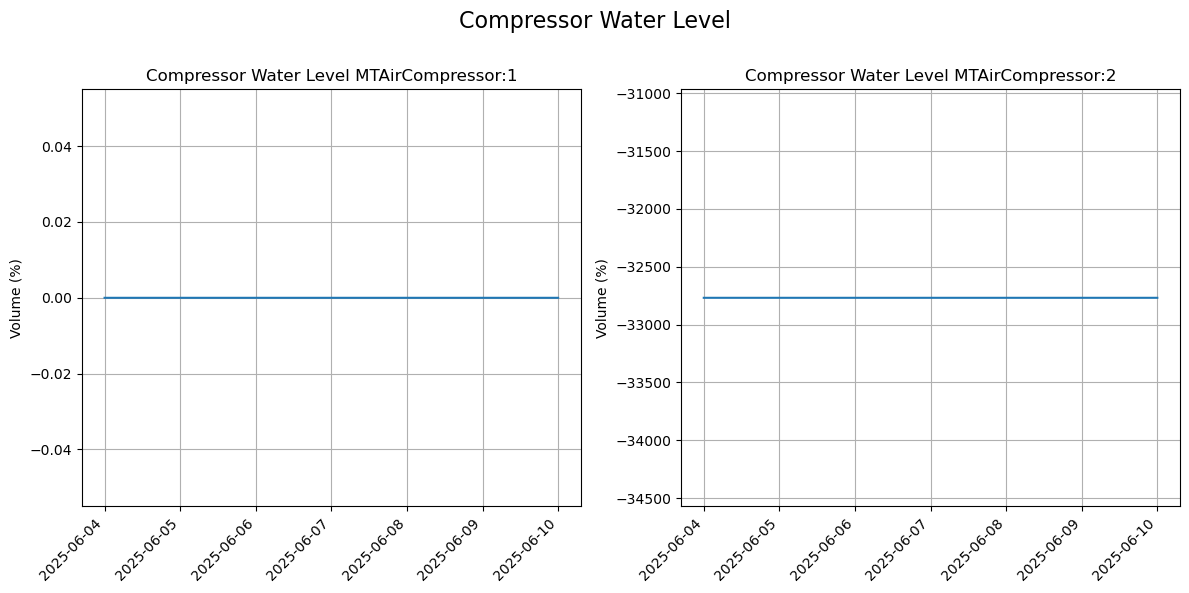

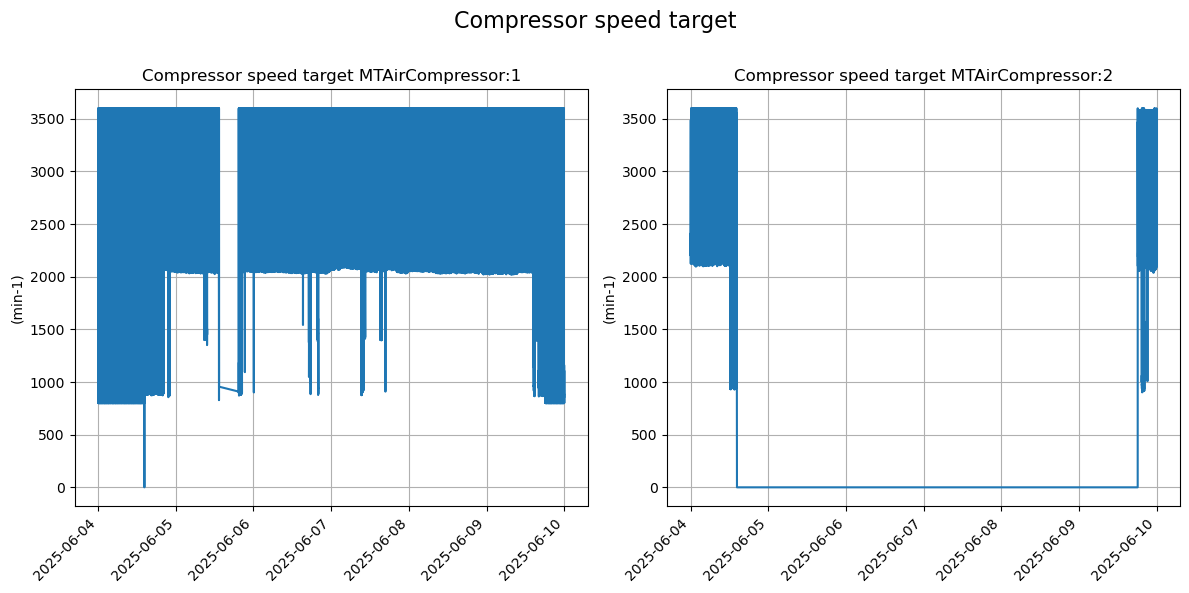

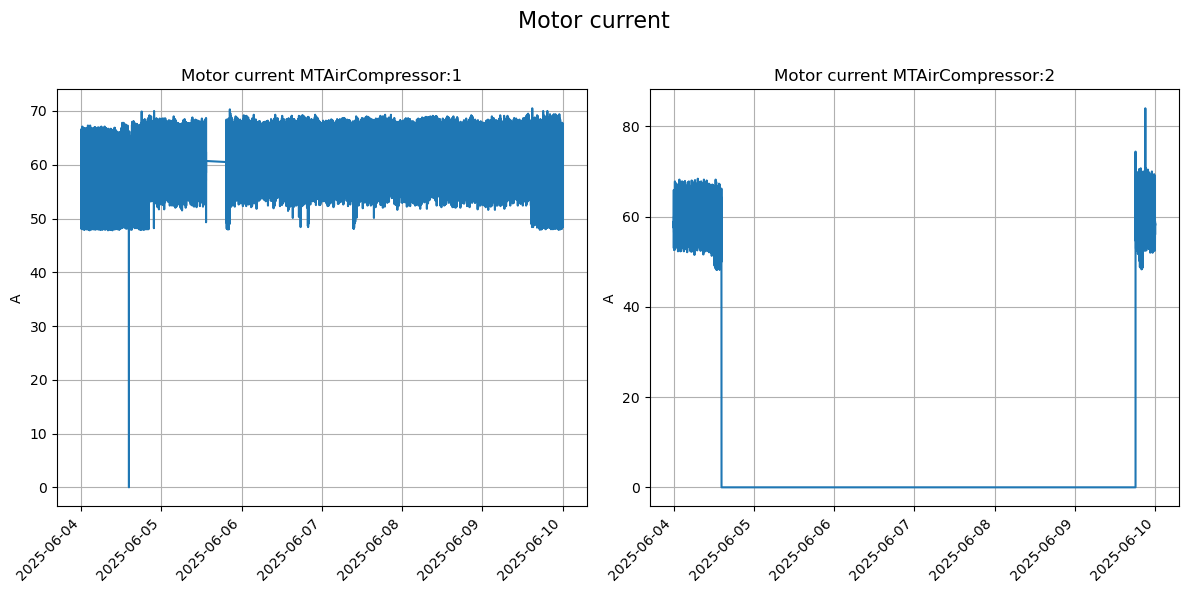

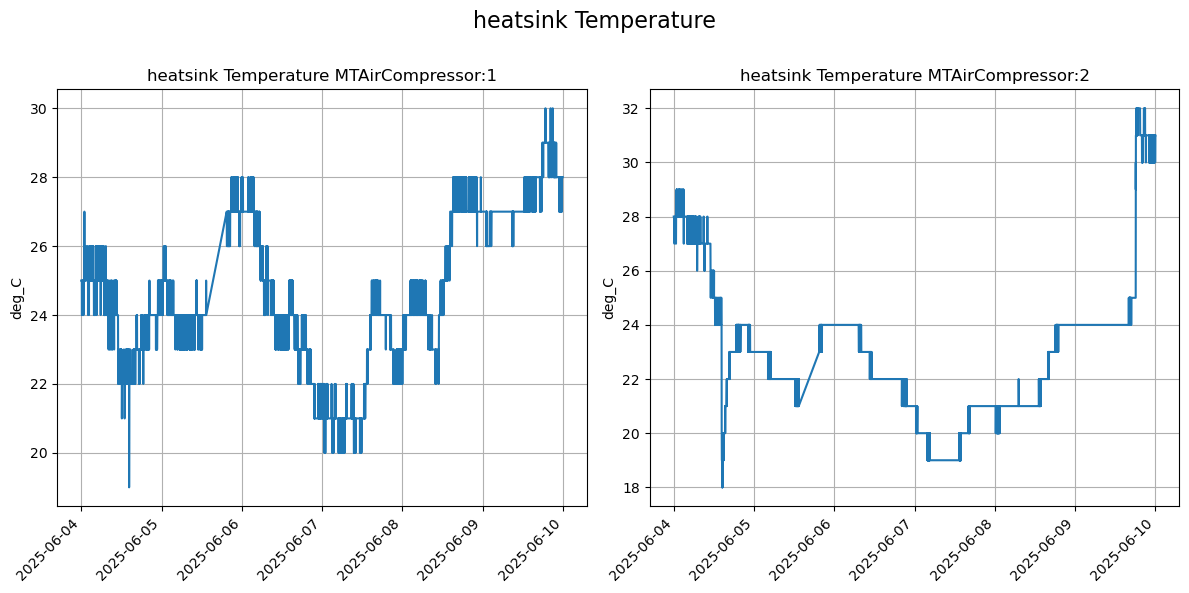

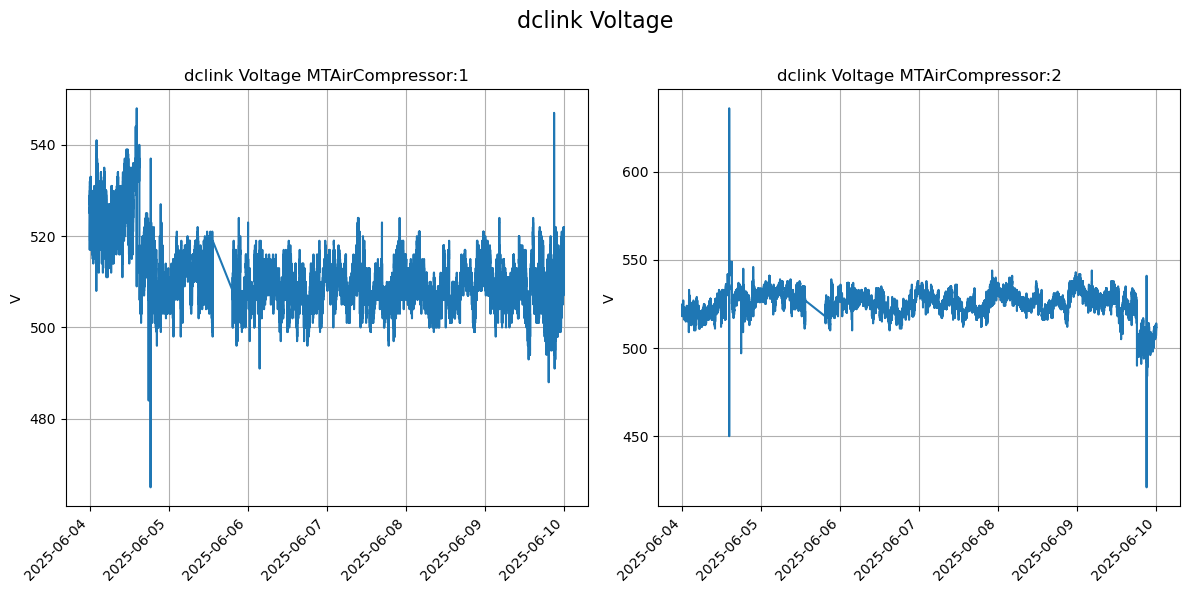

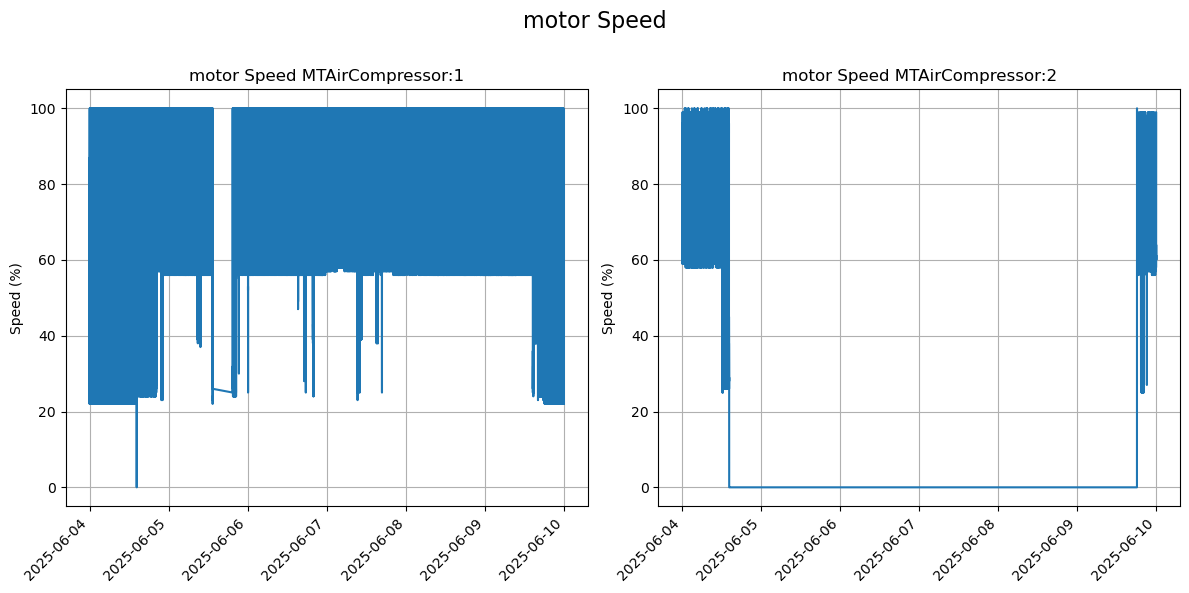

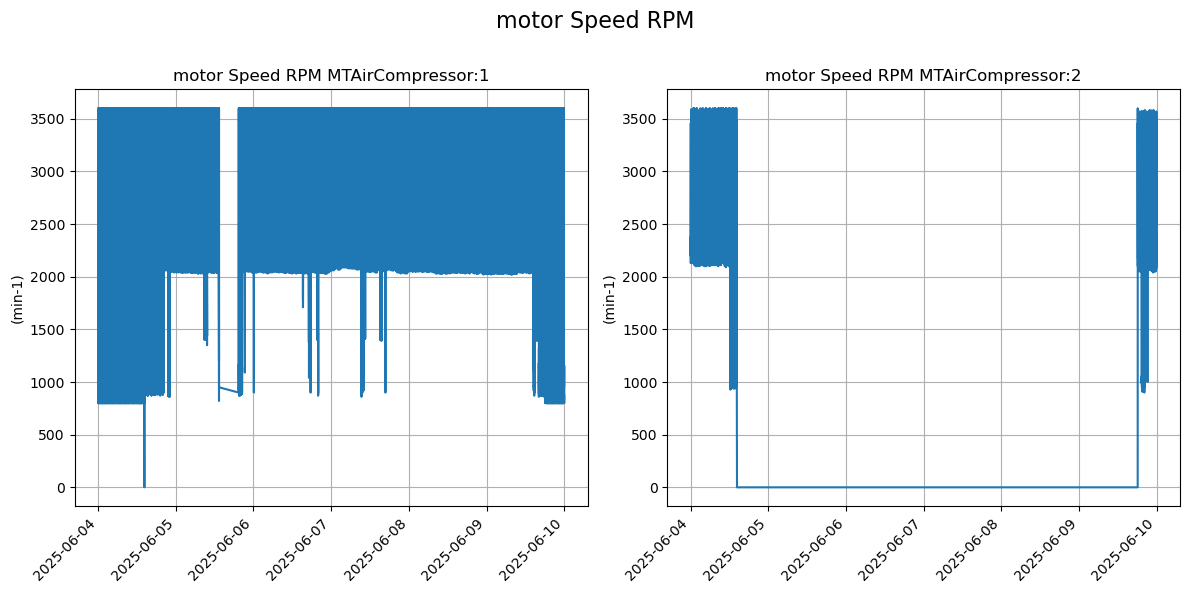

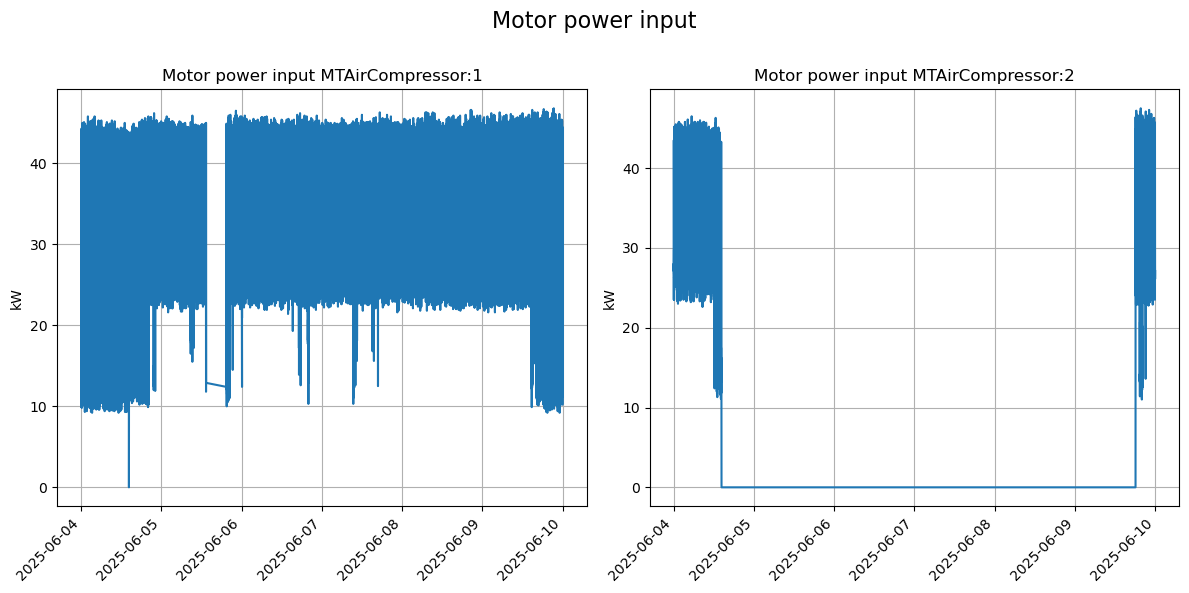

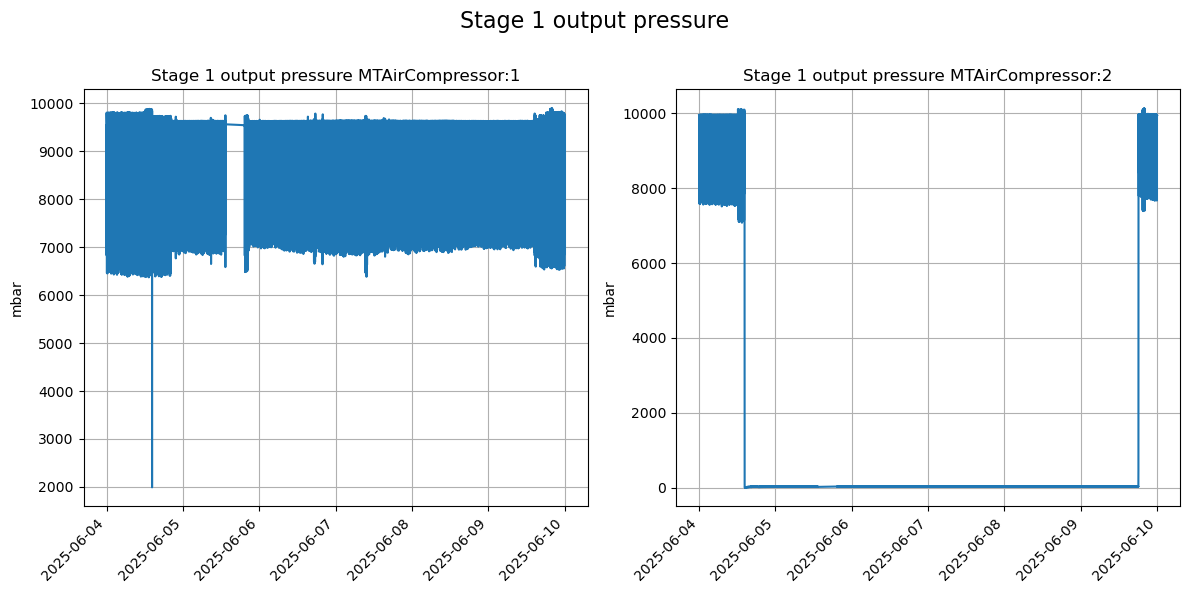

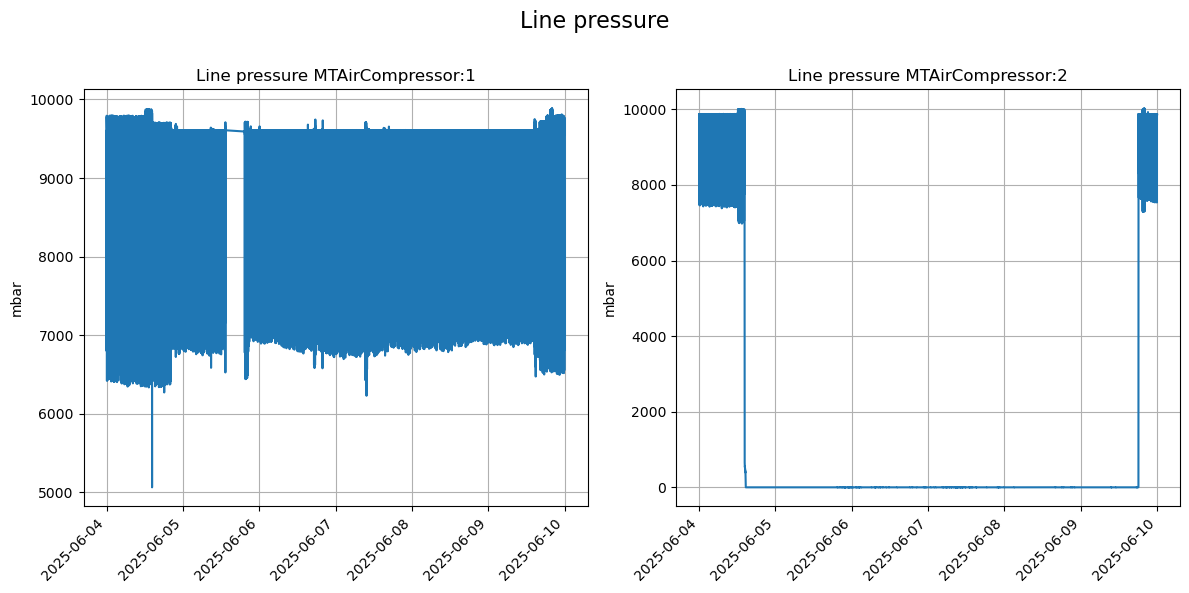

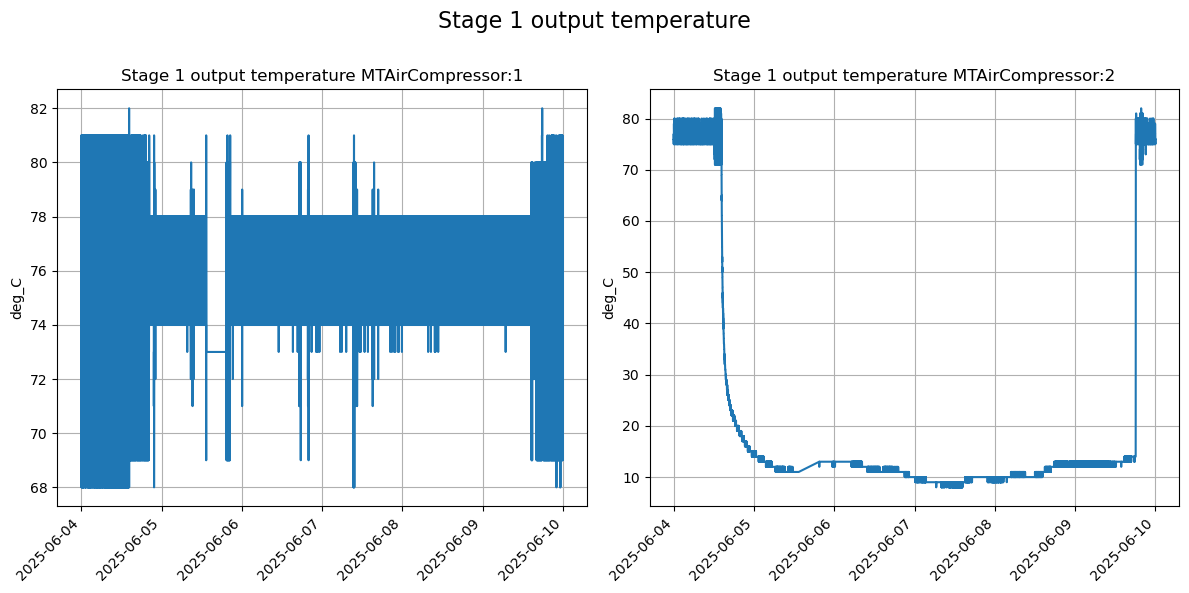

In [33]:
plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='compressorVolumePercentage',
                ylabel='Volume (%)',
                title='Compressor Volume')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='waterLevel',
                ylabel='Volume (%)',
                title='Compressor Water Level')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='targetSpeed',
                ylabel='(min-1)',
                title='Compressor speed target')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='motorCurrent',
                ylabel='A',
                title='Motor current')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='heatsinkTemperature',
                ylabel='deg_C',
                title='heatsink Temperature')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='dclinkVoltage',
                ylabel='V',
                title='dclink Voltage')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='motorSpeedPercentage',
                ylabel='Speed (%)',
                title='motor Speed')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='motorSpeedRPM',
                ylabel='(min-1)',
                title='motor Speed RPM')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='motorInput',
                ylabel='kW',
                title='Motor power input')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='stage1OutputPressure',
                ylabel='mbar',
                title='Stage 1 output pressure')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='linePressure',
                ylabel='mbar',
                title='Line pressure')

plot_compressor(times1, salIndex1, times2, salIndex2, 
                variable='stage1OutputTemperature',
                ylabel='deg_C',
                title='Stage 1 output temperature')

Although the log_event doesn't record any failures for compressor 1, we can see that both compressors 1 and 2 have a failure on July 4th.

Compressor 1 recovers immediately afterward, but compressor 2 doesn't do so until the 9th. 

In addition, we can see another failure on compressor 1 on day 5, which recovers a few hours later.



Let's see in detail the behavior for days 4 and 5 of both compressors

In [34]:
def plot_compressors_same_day(times1, salIndex1, times2, salIndex2,
                                variable, ylabel, title,
                                day='2025-06-04'):

    day_dt = datetime.strptime(day, '%Y-%m-%d')

    datetime1 = Time(salIndex1['private_efdStamp'], format='unix').datetime
    datetime2 = Time(salIndex2['private_efdStamp'], format='unix').datetime

    mask1 = (datetime1 >= day_dt) & (datetime1 < day_dt.replace(hour=23, minute=59, second=59))
    mask2 = (datetime2 >= day_dt) & (datetime2 < day_dt.replace(hour=23, minute=59, second=59))

    day_times1 = datetime1[mask1]
    day_times2 = datetime2[mask2]
    day_vals1 = salIndex1.loc[mask1, variable]
    day_vals2 = salIndex2.loc[mask2, variable]

    plt.figure(figsize=(12, 6))
    plt.plot(day_times1, day_vals1, label='Compressor 1', color='blue')
    plt.plot(day_times2, day_vals2, label='Compressor 2', color='orange')

    plt.title(title)
    plt.xlabel('Time')
    plt.ylabel(ylabel)
    plt.legend()

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    for label in ax.get_xticklabels():
       label.set_rotation(45)
       label.set_ha('right')    
    for label in plt.gca().get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    plt.grid(True)
    plt.tight_layout()
    plt.show()

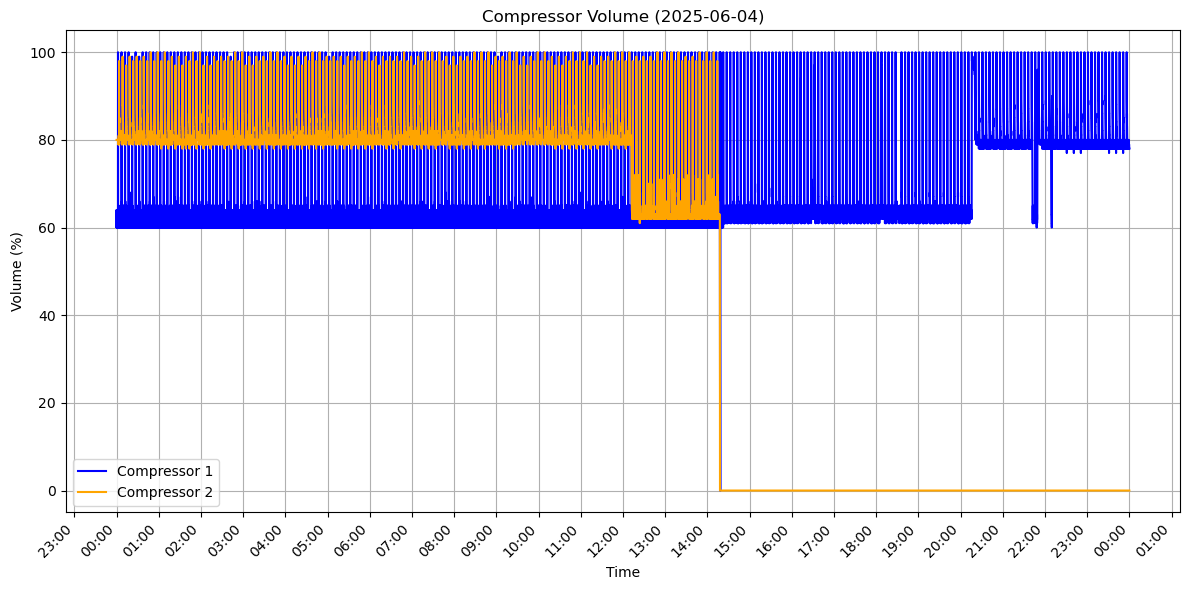

In [35]:
plot_compressors_same_day(salIndex1, salIndex1, salIndex2, salIndex2,
                           variable='compressorVolumePercentage',
                           ylabel='Volume (%)',
                           title='Compressor Volume (2025-06-04)')

Here we can see how on Juny 4th both compressors fail at 14:17 but compressor 1 recovers

Let's see what happened on June 5th

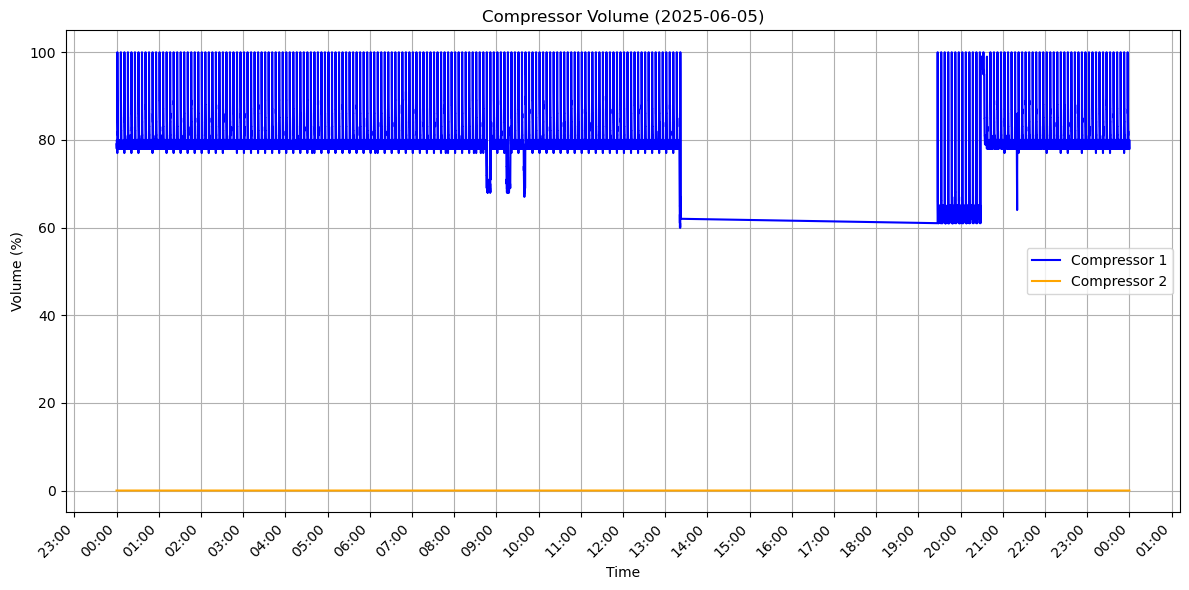

In [36]:
plot_compressors_same_day(salIndex1, salIndex1, salIndex2, salIndex2,
                           variable='compressorVolumePercentage',
                           ylabel='Volume (%)',
                           title='Compressor Volume (2025-06-05)',
                           day='2025-06-05')

The plot shows that compressor 1's output volume dropped after 1:00 PM and did not recover after 7:00 PM.

At 7:27 PM, a failure was recorded on compressor 1 on June 5, but not on compressor 2. 

However, there was no change for compressor 2. The compressor's output volume was already at 0.

Here's a breakdown by hour of the errors detected in telemetry.

In [37]:
def plot_compressors_same_hours(salIndex1, salIndex2,
                                variable, ylabel, title,
                                day='2025-06-04',
                                start_hour=14,
                                end_hour=15):

    day_dt = datetime.strptime(day, '%Y-%m-%d')

    datetime1 = Time(salIndex1['private_efdStamp'], format='unix').datetime
    datetime2 = Time(salIndex2['private_efdStamp'], format='unix').datetime

    start_dt = day_dt.replace(hour=start_hour, minute=0, second=0)
    end_dt = day_dt.replace(hour=end_hour, minute=0, second=0)

    mask1 = (datetime1 >= start_dt) & (datetime1 < end_dt)
    mask2 = (datetime2 >= start_dt) & (datetime2 < end_dt)

    day_times1 = datetime1[mask1]
    day_times2 = datetime2[mask2]
    day_vals1 = salIndex1.loc[mask1, variable]
    day_vals2 = salIndex2.loc[mask2, variable]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(day_times1, day_vals1, label='MTAirCompressor:1', color='blue')
    ax.plot(day_times2, day_vals2, label='MTAirCompressor:2', color='orange')

    ax.set_title(title)
    ax.set_xlabel('Time')
    ax.set_ylabel(ylabel)
    ax.legend()

    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

    ax.grid(True)
    fig.tight_layout()
    plt.show()


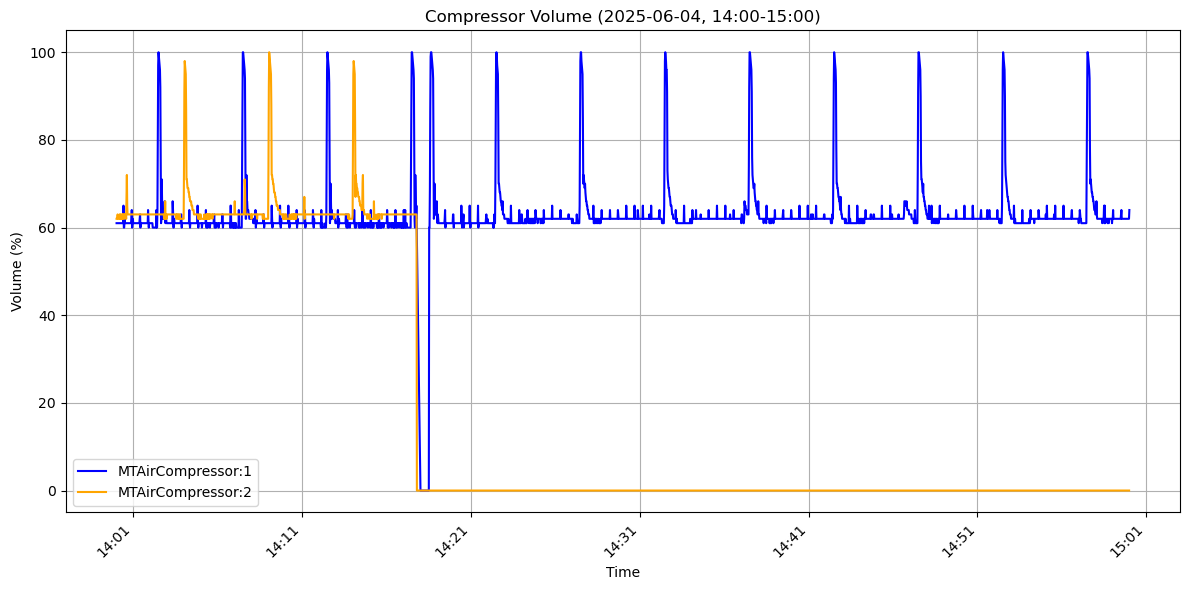

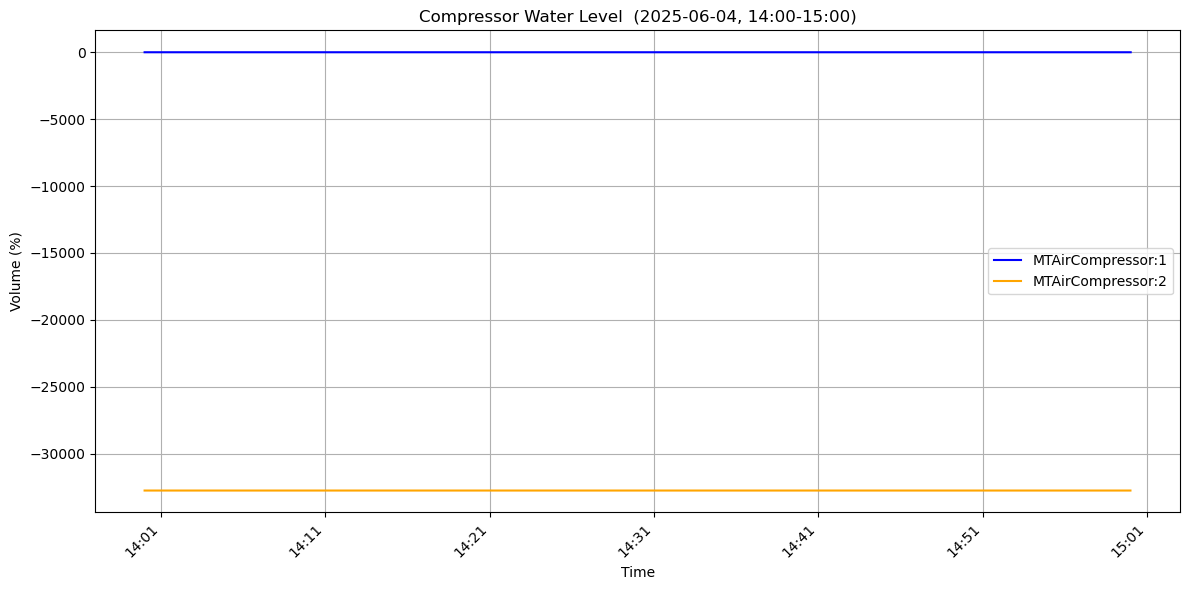

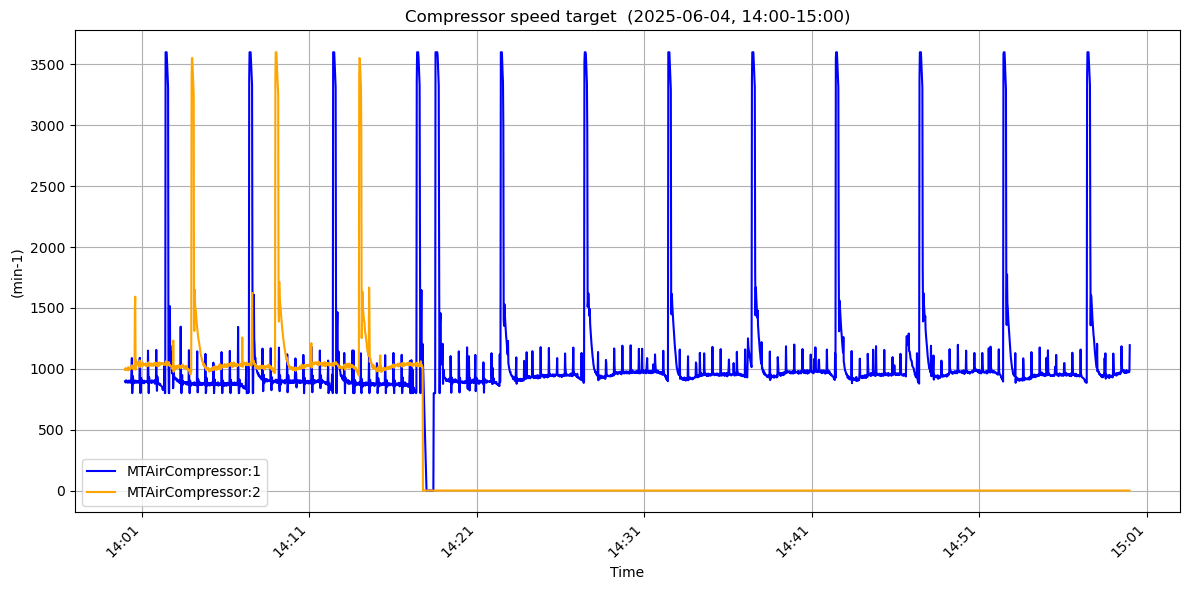

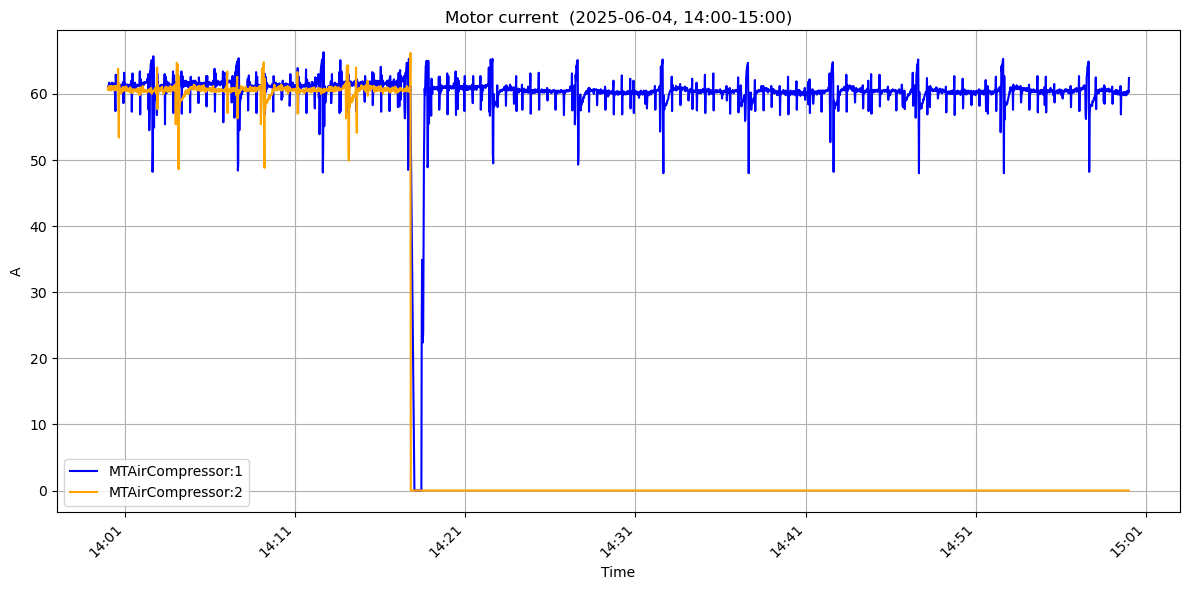

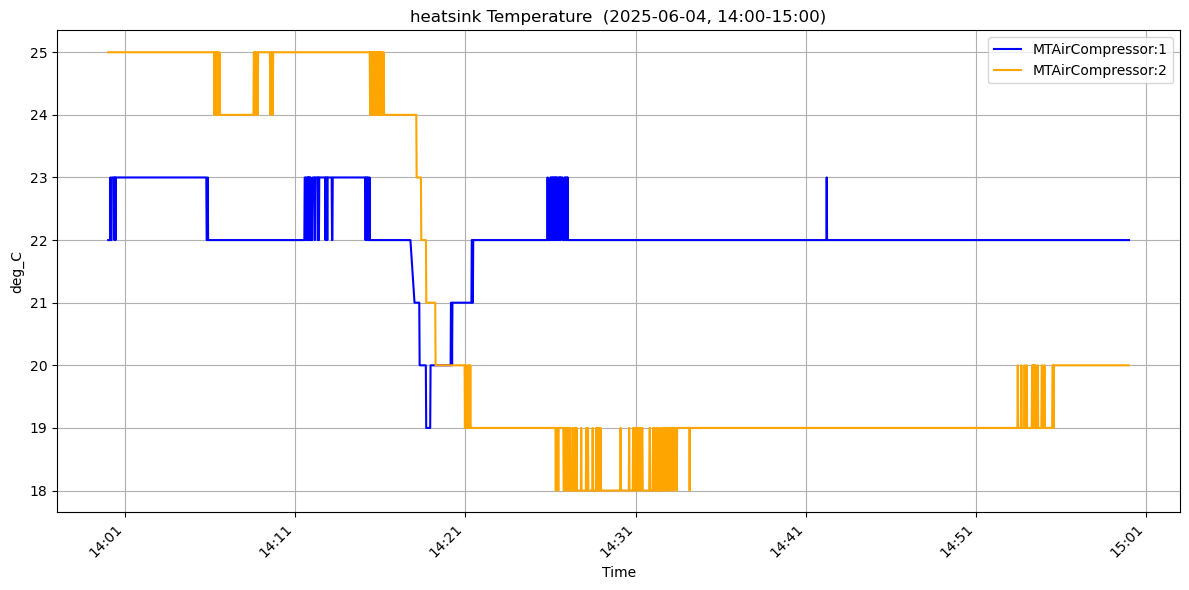

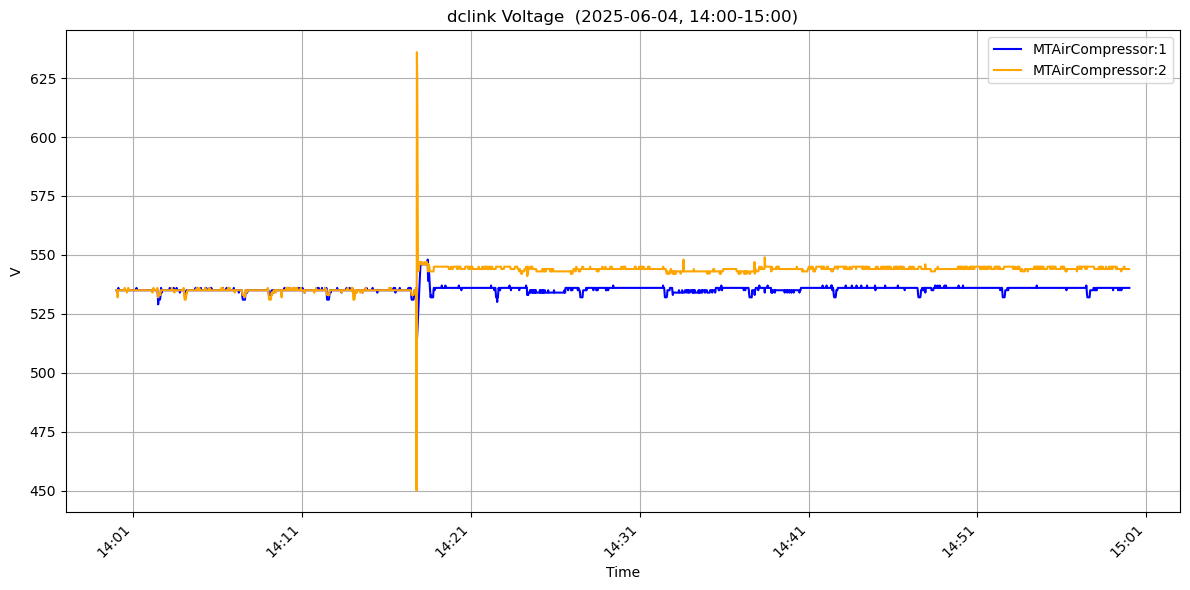

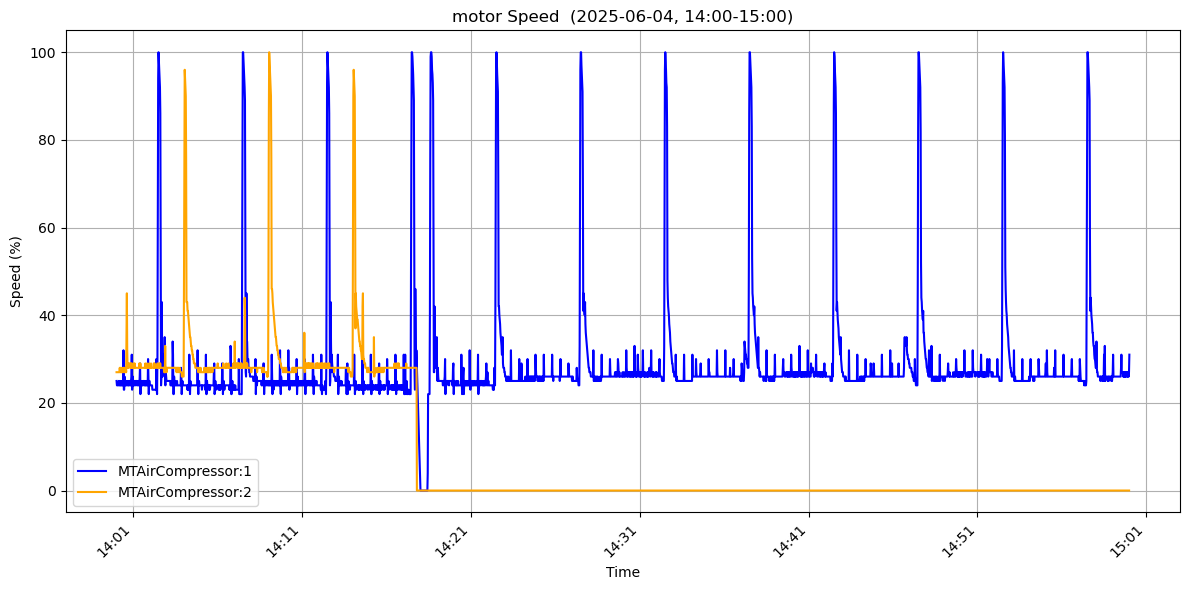

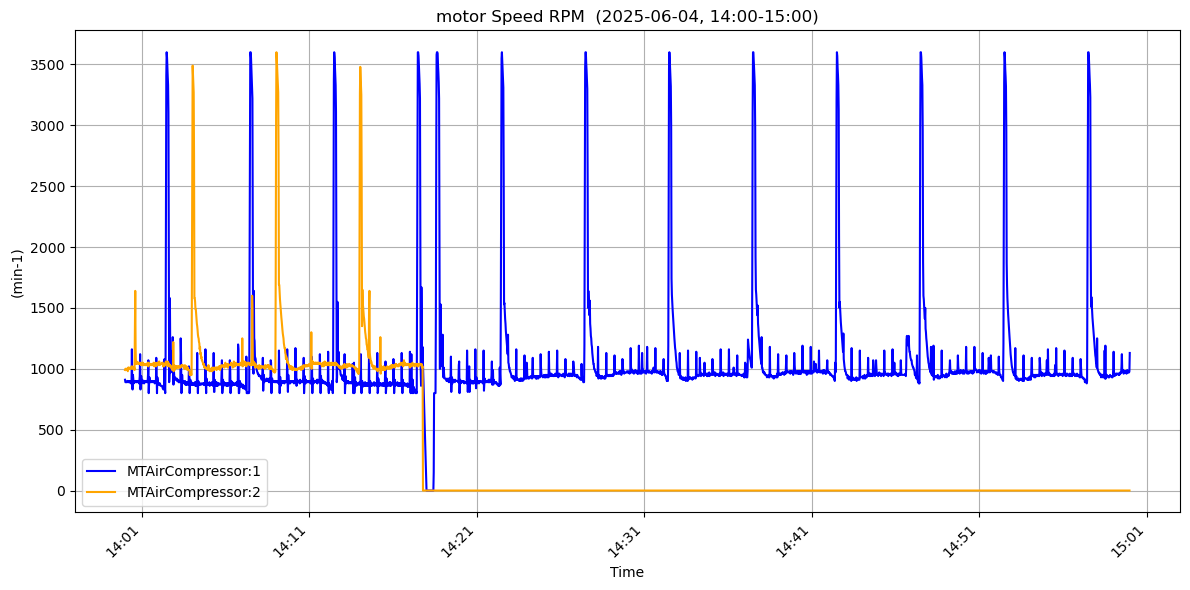

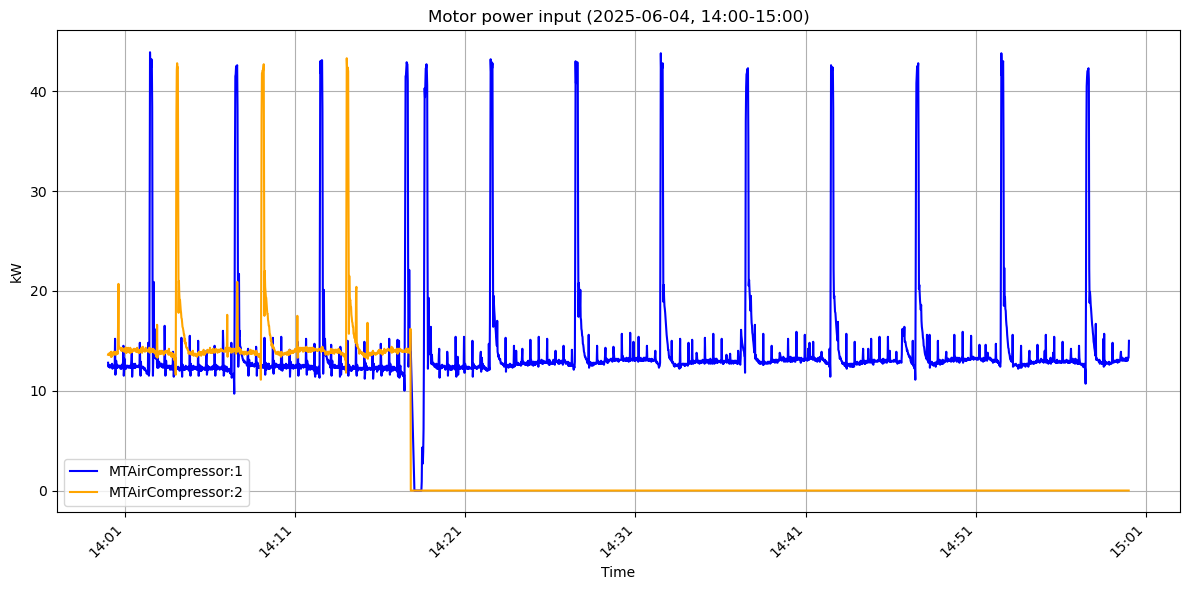

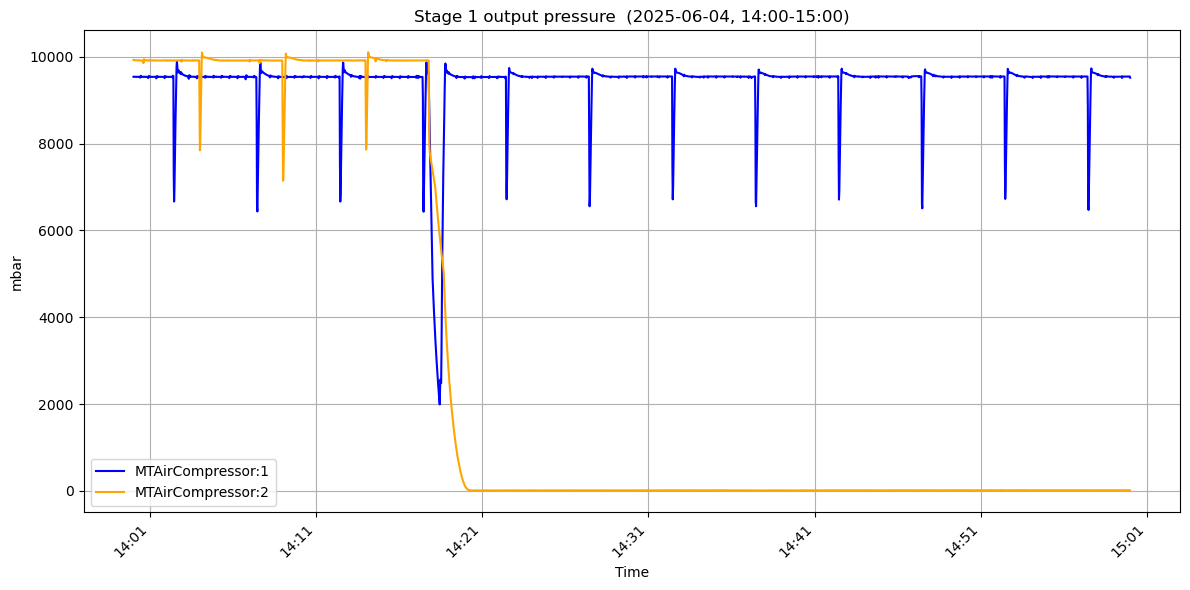

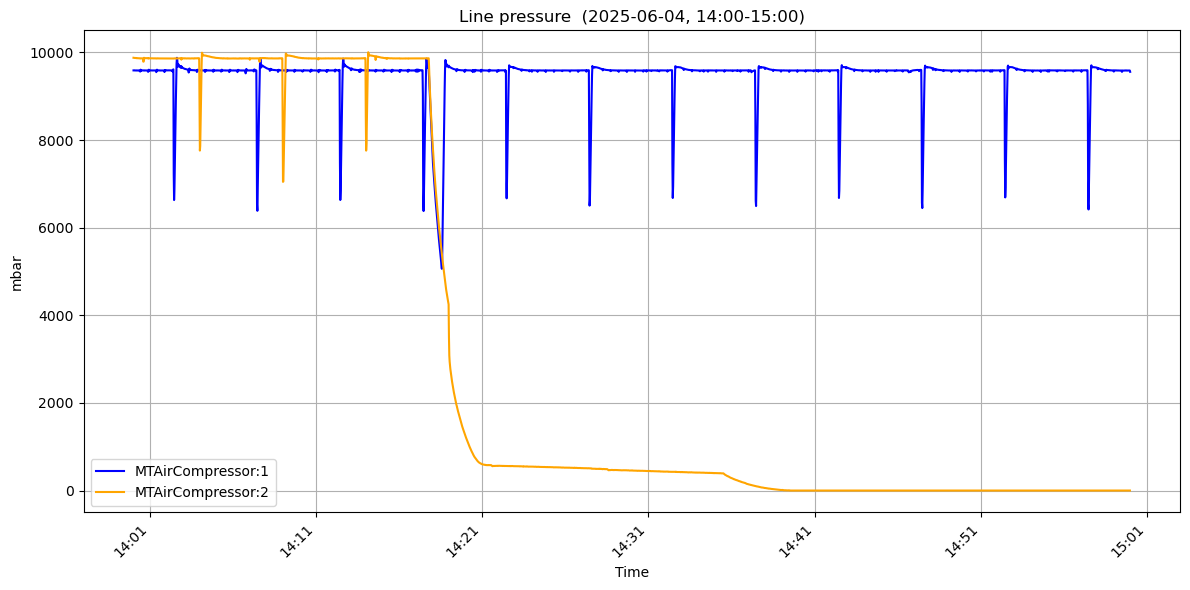

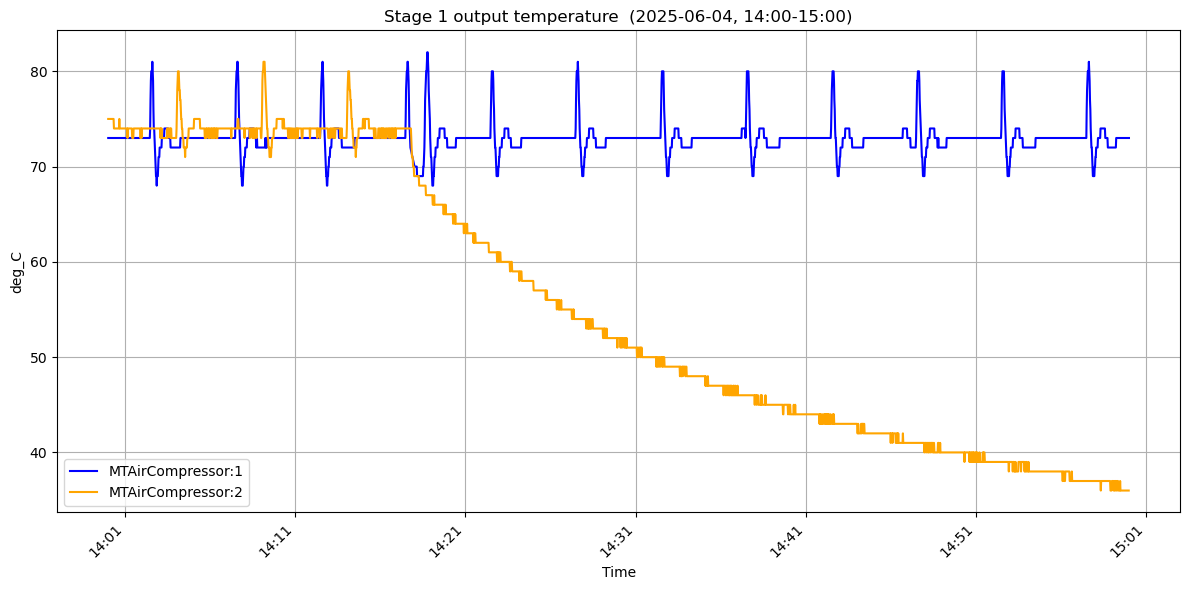

In [38]:
plot_compressors_same_hours(salIndex1, salIndex2,
                           variable='compressorVolumePercentage',
                           ylabel='Volume (%)',
                           title='Compressor Volume (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                           variable='waterLevel',
                           ylabel='Volume (%)',
                           title='Compressor Water Level  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                           variable='targetSpeed',
                           ylabel='(min-1)',
                           title='Compressor speed target  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                            variable='motorCurrent',
                            ylabel='A',
                            title='Motor current  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='heatsinkTemperature',
                             ylabel='deg_C',
                             title='heatsink Temperature  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='dclinkVoltage',
                             ylabel='V',
                             title='dclink Voltage  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='motorSpeedPercentage',
                             ylabel='Speed (%)',
                             title='motor Speed  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='motorSpeedRPM',
                             ylabel='(min-1)',
                             title='motor Speed RPM  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='motorInput',
                             ylabel='kW',
                             title='Motor power input (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='stage1OutputPressure',
                             ylabel='mbar',
                             title='Stage 1 output pressure  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='linePressure',
                             ylabel='mbar',
                             title='Line pressure  (2025-06-04, 14:00-15:00)')

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='stage1OutputTemperature',
                             ylabel='deg_C',
                             title='Stage 1 output temperature  (2025-06-04, 14:00-15:00)')

Here we can see in more detail that the failure detected in compressor 2 at 14:17 on June 4 also occurs for compressor 1 but it recovers

For both compressors the volume, the compressor speed target, the motor current, the motor speed, the motor power input drops to 0.


However, the Stage 1 output pressure  or the line pressure although there is a fault in both compressors only compressor 2 reaches the value 0. And the dclink VOltage seems to suffer a greater change.

Let's see what happens on June 5th

In [ ]:
plot_compressors_same_hours(salIndex1, salIndex2,
                           variable='compressorVolumePercentage',
                           ylabel='Volume (%)',
                           title='Compressor Volume (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                           variable='waterLevel',
                           ylabel='Volume (%)',
                           title='Compressor Water Level  (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                           variable='targetSpeed',
                           ylabel='(min-1)',
                           title='Compressor speed target (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                            variable='motorCurrent',
                            ylabel='A',
                            title='Motor current  (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='heatsinkTemperature',
                             ylabel='deg_C',
                             title='heatsink Temperature  (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='dclinkVoltage',
                             ylabel='V',
                             title='dclink Voltage (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='motorSpeedPercentage',
                             ylabel='Speed (%)',
                             title='motor Speed  (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='motorSpeedRPM',
                             ylabel='(min-1)',
                             title='motor Speed RPM  (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='motorInput',
                             ylabel='kW',
                             title='Motor power input (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='stage1OutputPressure',
                             ylabel='mbar',
                             title='Stage 1 output pressure  (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='linePressure',
                             ylabel='mbar',
                             title='Line pressure  (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)

plot_compressors_same_hours(salIndex1, salIndex2, 
                             variable='stage1OutputTemperature',
                             ylabel='deg_C',
                             title='Stage 1 output temperature  (2025-06-05, 17:00-18:00)',
                            day='2025-06-05',
                            start_hour=13,
                            end_hour=21)


Although there is no record of a failure for compressor 1, we can see in the telemetry that it failed for several hours, from around 13:18 on the 5th until 19:27.
                                                                                                      
The compressor volume dropped to 60% and then recovered. The compressor speed target, motor speed, and motor power input also dropped, but I reached 0.

## Event errors

In [ ]:
events_error

When viewing the table, something strange occurs. There is no record of a failure for June 4th; there is only one for the 5th.

Let's try to detect where the failure came from

In [ ]:
error_columns = [ 'communicationVSDE504', 'compressorDischargeTemperatureE403',
                  'condensateDrainE414', 'controllerHardwareE409', 'coolingE410',
                  'dischargeOverPressureE405', 'dischargePressureSensorB2E407',
                  'dischargeTemperatureSensorR2E408', 'dryerE413',
                  'emergencyStopActivatedE401', 'externalFaultE412', 'heavyStartupE416',
                  'highMotorTemperatureM1E402', 'linePressureSensorB1E406',
                  'lockedVSDE502', 'noPressureBuildUpE415', 'oilPressureLowE411',
                  'powerSupplyFailureE400', 'preAdjustmentE501', 'preAdjustmentVSDE500',
                  'readFaultVSDE507', 'seeVSDDisplayE509', 'speedBelowMinLimitE510',
                  'startTemperatureLowE404', 'stopInputEMVSDE506', 'stopInputVSDEME508',
                  'stopPressedVSDE505', 'writeFaultVSDE503']

In [ ]:
events_error_2 = events_error[events_error['private_identity']=="MTAirCompressor:2"]

for row in error_columns:
    if events_error_2[row].any() == True:
        print(row)

In [ ]:
events_error_1 = events_error[events_error['private_identity']=="MTAirCompressor:1"]

for row in error_columns:
    if events_error_1[row].any() == True:
        print(row)


The failure from June 5th is the only one listed in the table, however, none of the possible failures recorded the error.

For June 4th, the information doesn't even exist.